In [1]:
import pandas as pd 
from pathlib import Path
import warnings

In [2]:
base_path = Path('/Users/anuj/Documents/CodeBase/Bioinformatics_projects/biological-age-prediction/data/raw')

In [3]:
for year_folder in base_path.iterdir():
    for file in year_folder.glob("*.xpt"):
        print(file.stem.split("_"))

['P', 'HSCRP']
['P', 'DEMO']
['P', 'GLU']
['P', 'CBC']
['P', 'HDL']
['P', 'BIOPRO']
['P', 'GHB']
['BIOPRO', 'G']
['GHB', 'G']
['DEMO', 'G']
['HDL', 'G']
['GLU', 'G']
['CBC', 'G']
['CBC', 'H']
['GLU', 'H']
['HDL', 'H']
['DEMO', 'H']
['GHB', 'H']
['BIOPRO', 'H']
['CBC', 'I']
['GLU', 'I']
['HSV', 'I']
['HDL', 'I']
['DEMO', 'I']
['GHB', 'I']
['BIOPRO', 'I']


In [4]:
df = pd.read_sas(file)

print(df.shape)
print(df.head())

(6744, 38)
      SEQN  LBXSAL  LBDSALSI  LBXSAPSI  LBXSASSI  LBXSATSI  LBXSBU  LBDSBUSI  \
0  83732.0     4.6      46.0      52.0      21.0      25.0    13.0      4.64   
1  83733.0     4.5      45.0      47.0      31.0      35.0    10.0      3.57   
2  83734.0     4.5      45.0      46.0      30.0      29.0    26.0      9.28   
3  83735.0     3.8      38.0      65.0      23.0      26.0    13.0      4.64   
4  83736.0     4.3      43.0      46.0      20.0      13.0    12.0      4.28   

   LBXSC3SI  LBXSCA  ...  LBXSPH  LBDSPHSI  LBXSTB  LBDSTBSI  LBXSTP  \
0      25.0     9.8  ...     4.7     1.518     0.5      8.55     7.5   
1      27.0     9.8  ...     4.4     1.421     0.6     10.26     7.4   
2      24.0     9.7  ...     3.6     1.162     0.5      8.55     7.3   
3      24.0     8.9  ...     3.8     1.227     0.3      5.13     6.1   
4      24.0     9.3  ...     3.2     1.033     0.3      5.13     7.7   

   LBDSTPSI  LBXSTR  LBDSTRSI  LBXSUA  LBDSUASI  
0      75.0   158.0     1

Now - need to code this in 3 functions as to load_data, read_xpt and extract_name.

In [5]:
def extract_name(file: Path) -> str:
    parts = file.stem.split('_')

    if parts[0] == 'P':
        return parts[1]
    return parts[0]

In [6]:
def read_xpt(file: Path) -> pd.DataFrame:
    return pd.read_sas(file, format='xport', encoding= 'latin1')
   

In [7]:
def load_all_data(base_path: Path) -> dict:
    data = {}

    for year_folder in base_path.iterdir():
        if not year_folder.is_dir():
            continue

        year = year_folder.name

        for file in year_folder.glob('*.xpt'):
            dataset_name = extract_name(file)

            try:
                df = read_xpt(file)

                if 'year' not in df.columns:
                    df["year"] = year

                # flat dictionary using tuple key
                key = (year, dataset_name)
                data[key] = df

            except Exception as e:
                print(f'Error reading {file}: {e}')
                continue

    return data


In [8]:
data = load_all_data(base_path)

/var/folders/sl/clykmrq15rd0ksl37m6bnksw0000gn/T/ipykernel_8321/3693786825.py:2: UserWarning: xport file may be corrupted.
  return pd.read_sas(file, format='xport', encoding= 'latin1')


In [9]:
print(len(data))

26


In [10]:
df = list(data.values())[0]

In [11]:
df.shape

(17047, 4)

## Merge_data.py - now will be merging the data

In [12]:
from typing import Tuple, List

def get_metadata(data: dict) -> Tuple[List[str], List[str]]:
    
    years = list(set(k[0] for k in data.keys()))
    features = list(set(k[1] for k in data.keys()))

    return years, features

In [13]:
def yearly_features_merged(data: dict, year: str, features: list) -> pd.DataFrame:


    df_merged = data[(year, 'DEMO')].copy()

    for feature in features:

        if feature == 'DEMO':
            continue

        if (year, feature) not in data:
            continue

        df_feature = data[(year, feature)]

        df_feature = df_feature.drop(columns = ['year'], errors = 'ignore')

        df_merged = pd.merge(df_merged, df_feature, on = "SEQN", how = "left")

    return df_merged
        

In [14]:
def all_years_data(data: dict) -> dict:
    
    years, features = get_metadata(data)
    
    merged_data = {}

    for year in years:
        merged_data[year] = yearly_features_merged(data, year, features)

    return merged_data
        

In [15]:
def combine_years(merged_data: dict)->pd.DataFrame:
    dfs =[]

    for year, df_year in merged_data.items():
        df_year = df_year.copy()
        df_year['year'] = year

        dfs.append(df_year)

    return pd.concat(dfs, ignore_index=True)
    

In [16]:
for year, files in data.keys():
    if year == '2011-12':
        print(files)
    

BIOPRO
GHB
DEMO
HDL
GLU
CBC


In [17]:
for year, files in data.keys():
    if year == '2013-14':
        print(files)

CBC
GLU
HDL
DEMO
GHB
BIOPRO


In [18]:
for year, files in data.keys():
    if year == '2015-16':
        print(files)

CBC
GLU
HSV
HDL
DEMO
GHB
BIOPRO


In [19]:
for year, files in data.keys():
    if year == '2017-20':
        print(files)

HSCRP
DEMO
GLU
CBC
HDL
BIOPRO
GHB


In [20]:
data['2017-20', 'HSCRP']

,SEQN,LBXHSCRP,LBDHRPLC,year
0,1.103320e+05,5.397606e-79,5.397606e-79,2017-20
1,5.397607e-79,-1.525879e-05,1.182054e-29,2017-20
2,1.000000e+00,1.103320e+05,5.482351e-79,2017-20
3,-1.855469e-04,5.397607e-79,-3.051758e-05,2017-20
4,-4.622072e-02,-4.621887e-02,5.397961e-79,2017-20
...,...,...,...,...
17042,5.878628e+57,5.397607e-79,5.397606e-79,2017-20
17043,5.397606e-79,5.397607e-79,5.397606e-79,2017-20
17044,5.397606e-79,5.397607e-79,5.397607e-79,2017-20
17045,-2.938402e+56,-1.440000e+02,5.488689e-79,2017-20


### Inflammation data does not have squence! 

In [21]:
data['2017-20','BIOPRO'].head()

,SEQN,LBXSATSI,LBDSATLC,LBXSAL,LBDSALSI,LBXSAPSI,LBXSASSI,LBXSC3SI,LBXSBU,LBDSBUSI,...,LBDSCASI,LBXSCH,LBDSCHSI,LBXSTP,LBDSTPSI,LBXSTR,LBDSTRSI,LBXSUA,LBDSUASI,year
0,109264.0,8.0,5.397605e-79,4.3,43.0,172.0,18.0,26.0,9.0,3.21,...,2.350,170.0,4.396,6.9,69.0,54.0,0.610,3.5,208.2,2017-20
1,109266.0,15.0,5.397605e-79,3.8,38.0,74.0,14.0,25.0,8.0,2.86,...,2.200,199.0,5.146,6.8,68.0,86.0,0.971,4.9,291.5,2017-20
2,109271.0,8.0,5.397605e-79,3.8,38.0,88.0,14.0,30.0,8.0,2.86,...,2.225,148.0,3.827,7.3,73.0,101.0,1.140,5.0,297.4,2017-20
3,109273.0,35.0,5.397605e-79,4.6,46.0,70.0,27.0,27.0,11.0,3.93,...,2.425,168.0,4.344,7.4,74.0,178.0,2.010,5.2,309.3,2017-20
4,109274.0,19.0,5.397605e-79,4.0,40.0,49.0,20.0,28.0,11.0,3.93,...,2.275,105.0,2.715,6.8,68.0,151.0,1.705,5.1,303.3,2017-20


In [22]:
all_years = all_years_data(data)
df = combine_years(all_years)

print(df.shape)
print(df.columns)
print(df.head())

(45462, 129)
Index(['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN',
       'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM',
       ...
       'DMDMARTZ', 'WTINTPRP', 'WTMECPRP', 'WTSAFPRP', 'LBXHSCRP', 'LBDHRPLC',
       'LBXNRBC', 'LBDSATLC', 'LBDSGTLC', 'LBDSTBLC'],
      dtype='str', length=129)
      SEQN  SDDSRVYR  RIDSTATR  RIAGENDR  RIDAGEYR  RIDAGEMN  RIDRETH1  \
0  83732.0       9.0       2.0       1.0      62.0       NaN       3.0   
1  83733.0       9.0       2.0       1.0      53.0       NaN       3.0   
2  83734.0       9.0       2.0       1.0      78.0       NaN       3.0   
3  83735.0       9.0       2.0       2.0      56.0       NaN       3.0   
4  83736.0       9.0       2.0       2.0      42.0       NaN       4.0   

   RIDRETH3  RIDEXMON  RIDEXAGM  ...  DMDMARTZ  WTINTPRP  WTMECPRP  WTSAFPRP  \
0       3.0       1.0       NaN  ...       NaN       NaN       NaN       NaN   
1       3.0       1.0       NaN  ...       NaN       NaN       NaN       NaN

In [23]:
df["LBXHSCRP"].isna().mean()

np.float64(0.9967885266816242)

In [24]:
df.isna().mean().sort_values(ascending=False).head(20)

LBDHRPLC    0.996789
LBXHSCRP    0.996789
DMQADFC     0.964344
LBXHE2      0.938080
LBDINSI     0.936628
LBXIN       0.936628
RIDAGEMN    0.934429
DMDYRUSZ    0.933395
LBXHE1      0.925366
RIDEXAGY    0.924816
WTSAFPRP    0.888038
RIDEXPRG    0.875082
DMDYRSUS    0.863248
PHAFSTHR    0.857947
PHAFSTMN    0.857947
DMDEDUC3    0.822951
DMDMARTZ    0.796929
LBDSATLC    0.791628
LBDSGTLC    0.791628
LBDSTBLC    0.791584
dtype: float64

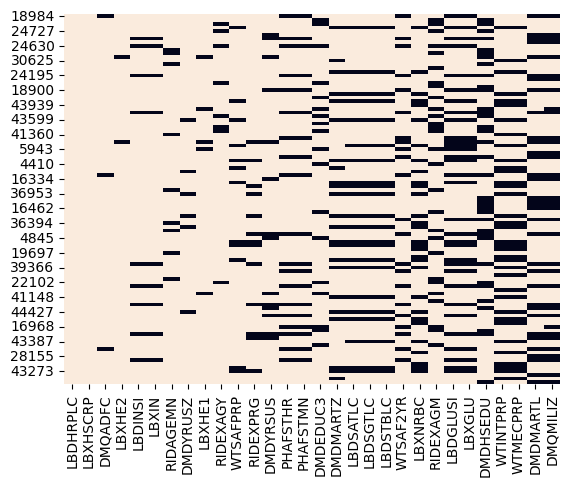

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# sample columns (too many columns make a heatmap unreadable)
cols = df.isna().mean().sort_values(ascending=False).head(30).index
sns.heatmap(df[cols].isna().astype(int).sample(100), cbar=False)
plt.show()

In [26]:
def drop_high_missing_columns(df, threshold =0.6):
    
    valid_cols =[]

    for col in df.columns:
        if df[col].isna().mean() < threshold:
            
            valid_cols.append(col)

    return df[valid_cols]


def create_dataset(df: pd.DataFrame) -> pd.DataFrame:

    print(f"Original shape: {df.shape}")

    # Step 1: Drop columns with too many missing values
    df_clean = drop_high_missing_columns(df, threshold=0.6)

    print(f"After dropping high-missing columns: {df_clean.shape}")

    return df_clean

In [27]:
df_clean=create_dataset(df)

Original shape: (45462, 129)
After dropping high-missing columns: (45462, 100)


In [28]:
df_clean.isna().mean().sort_values(ascending=False).head(20)

DMQMILIZ    0.594892
AIALANGA    0.422441
DMDEDUC2    0.421935
LBXSLDSI    0.383243
LBXSASSI    0.379460
LBDSCASI    0.379372
LBXSCA      0.379372
LBXSIR      0.379218
LBDSIRSI    0.379218
LBXSCK      0.379108
LBXSGB      0.378910
LBDSGBSI    0.378910
LBDSTPSI    0.378888
LBXSTP      0.378888
LBDSTRSI    0.378712
LBXSTR      0.378712
LBDSTBSI    0.378690
LBXSTB      0.378668
LBXSKSI     0.378646
LBXSUA      0.378558
dtype: float64

In [29]:
missing = df_clean.isna().mean()

print("0–20%:", (missing < 0.2).sum())
print("20–40%:", ((missing >= 0.2) & (missing < 0.4)).sum())
print("40–60%:", ((missing >= 0.4) & (missing < 0.6)).sum())

0–20%: 39
20–40%: 58
40–60%: 3


### make_interim file

In [30]:
from pathlib import Path
from typing import Dict, Any
import pandas as pd

from biological_age.data.load_data import load_all_data
from biological_age.data.merge_data import merge_all_years, combine_years

In [31]:
def provide_final_df(raw_dir):

    if not raw_dir.exists():
        raise FileNotFoundError(f'Directory not found {raw_dir}.')
    
    data = extract_name(raw_dir)

    if not data:
        raise ValueError('data not loaded from files')
    

    merge_data = merge_all_years(data)
    print(f'[info] years processed: {list(merge_data.keys())}')

    all_years = combine_years(merge_data)

    return all_years


In [32]:
def save_interim(df: pd.DataFrame, output_path: Path) -> None:
    
    output_path.parent.mkdir(parents=True, exist_ok=True)

    df.to_parquet(output_path, index=False)

    print(f"[INFO] Saved interim dataset to: {output_path}")


In [33]:
def run_make_interim(config: Dict[str, Any]):

    raw_dir = Path(config['paths']['raw'])
    output_path = Path(config['paths']['interim'])



    df = provide_final_df(raw_df)
    
    save_interim(df, output_path)
    

In [34]:
from pathlib import Path

import pandas as pd


CRP_COLUMNS = [
    "HSCRP",
    "LBXHSCRP",
    "HSV",
    "CRP"
]


def validate_dataset(df: pd.DataFrame) -> None:
    """
    Run basic validation checks on dataset integrity.
    """

    print("\n[INFO] Running dataset validation...")

    # Dataset shape
    print(f"[INFO] Dataset shape: {df.shape}")

    # Duplicate rows
    duplicate_rows = df.duplicated().sum()
    print(f"[INFO] Duplicate rows: {duplicate_rows}")

    # Duplicate participant IDs
    if "SEQN" in df.columns:
        duplicate_seqn = df["SEQN"].duplicated().sum()
        print(f"[INFO] Duplicate SEQN values: {duplicate_seqn}")

    # Missing value summary
    missing_ratio = (
        df.isna()
        .mean()
        .sort_values(ascending=False)
    )

    print("\n[INFO] Top 10 columns by missing ratio:")
    print(missing_ratio.head(10))

    # Data type summary
    print("\n[INFO] Data type summary:")
    print(df.dtypes.value_counts())


def remove_crp_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove CRP-related columns permanently.
    """

    existing_crp_cols = [
        col for col in CRP_COLUMNS
        if col in df.columns
    ]

    if existing_crp_cols:
        df = df.drop(
            columns=existing_crp_cols,
            errors="ignore",
        )

        print(
            f"\n[INFO] Dropped CRP columns: "
            f"{existing_crp_cols}"
        )

    return df


def remove_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove duplicate rows and duplicate participants.
    """

    # Remove exact duplicate rows
    before_rows = len(df)

    df = df.drop_duplicates()

    after_rows = len(df)

    print(
        f"\n[INFO] Removed "
        f"{before_rows - after_rows} duplicate rows"
    )

    # Remove duplicate participant IDs
    if "SEQN" in df.columns:

        before_seqn = len(df)

        df = df.drop_duplicates(
            subset="SEQN",
        )

        after_seqn = len(df)

        print(
            f"[INFO] Removed "
            f"{before_seqn - after_seqn} "
            f"duplicate SEQN entries"
        )

    return df


def create_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """
    Main dataset creation pipeline.
    """

    print("\n[INFO] Creating processed dataset...")
    print(f"[INFO] Original shape: {df.shape}")

    # Remove CRP-related columns
    df = remove_crp_columns(df)

    # Remove duplicates
    df = remove_duplicates(df)

    # Reset index
    df = df.reset_index(drop=True)

    print(f"\n[INFO] Final shape: {df.shape}")

    # Validate dataset
    validate_dataset(df)

    return df


def save_dataset( df: pd.DataFrame, save_path: Path ) -> None:
    """
    Save processed dataset as parquet.
    """

    save_path.parent.mkdir(parents=True, exist_ok=True)

    df.to_parquet(
        save_path,
        index=False,
    )

    print(
        f"\n[INFO] Dataset saved to:\n{save_path}"
    )

In [35]:
from pathlib import Path
import pandas as pd

CRP_Columns = ["HSCRP", "LBXHSCRP", "CRP", "HSV"]

In [36]:
def validate_dataset(df):
    duplicate_rows = df.duplicated().sum()
    print("Duplicated Row: ",duplicate_rows)

    if "SEQN" in df.columns:
        duplicate_seqn = df['SEQN'].duplicated().sum()

        print('Duplicated SEQN: ', duplicate_seqn)


    missing_ration = (df.isna().mean().sort_values(ascending = False))
    


In [37]:
import sys
print(sys.executable)

/Users/anuj/Documents/CodeBase/Bioinformatics_projects/biological-age-prediction/.venv/bin/python


In [38]:
def removing_crp_columns(df):

    for columns in CRP_Columns:
        if df.columns ==  columns:
            df = df.drop(columns)

In [39]:
def main():
    

    config = load_config()

    run_make_interim(config)

    interim_path = Path(config["paths"]["interim"])

    df = pd.read_parquet(interim_path)

    processed_df = create_dataset(df)

    processed_path = Path(config["paths"]["processed"])

    save_dataset(processed_df, processed_path)


In [ ]:
df.columns()